Tools: Python, Jupyter Notebook, BeautifulSoup, Selenium, pandas, matplotlib
Part 1: BeautifulSoup (CoinGecko)
Using what you learned from scraping CoinGecko:
1. Scrape the top 50 coins from CoinGecko and save the raw data to a CSV
2. Clean the numeric columns (price, market cap, volume, % changes)
3. Answer these questions using pandas:
  - Which coin had the biggest 24h gain?
  - Which coin had the biggest 24h loss?
  - What is the total market cap of the top 50 coins combined?
  - How many coins are down over 7 days?
4. Create two matplotlib charts of your choice that tell a story about the data. Each chart must have a title, labelled axes.

Answer

In [19]:
! pip install requests beautifulsoup4 selenium

! pip install lxml

! pip install webdriver-manager

! pip install pandas matplotlib

print("Libraries ready to import!")

Libraries ready to import!


In [21]:
import time  

import requests 
from bs4 import BeautifulSoup 

from selenium import webdriver 
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful.")

All imports successful.


In [22]:
chrome_options = Options()
chrome_options.add_argument("--headless")          
chrome_options.add_argument("--no-sandbox")         
chrome_options.add_argument("--disable-dev-shm-usage")  
chrome_options.add_argument("--disable-gpu")       
chrome_options.add_argument("--window-size=1920,1080")  

chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/122.0.0.0 Safari/537.36"
)

service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service, options=chrome_options)

print("Browser launched successfully!")
print(f"Chrome version: {driver.capabilities['browserVersion']}")

Browser launched successfully!
Chrome version: 146.0.7680.165


In [65]:
URL = "https://www.coingecko.com"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    )
}

response = requests.get(URL, headers=headers, timeout=15)

print(f"Status code: {response.status_code}")
print(f"Page size:   {len(response.text):,} characters")

Status code: 200
Page size:   1,634,304 characters


In [70]:
soup = BeautifulSoup(response.text, "lxml")
print("Page title:", soup.title.text.strip())

table = soup.find("table")
if table:
    print("Table found!")
    # We will use tbody specifically for the data rows
    tbody = table.find("tbody")
else:
    print("No table found.")

Page title: Cryptocurrency Prices, Charts, and Crypto Market Cap | CoinGecko
Table found!


In [72]:
coin_data = []

if tbody:
    # Get only the first 50 rows
    rows = tbody.find_all("tr")[:50] 
    
    for row in rows:
        cells = row.find_all("td")
        if len(cells) < 8:
            continue

        # Extracting based on column position
        rank = cells[1].get_text(strip=True)
        
        # Splitting Name and Ticker
        name_cell = cells[2].get_text(separator="|", strip=True).split("|")
        name = name_cell[0]
        ticker = name_cell[1] if len(name_cell) > 1 else ""
        
        # Appending to our list
        coin_data.append({
            "Rank":       rank,
            "Name":       name,
            "Ticker":     ticker,
            "Price":      cells[3].get_text(strip=True),
            "1h %":       cells[4].get_text(strip=True),
            "24h %":      cells[5].get_text(strip=True),
            "7d %":       cells[6].get_text(strip=True),
            "Volume 24h": cells[7].get_text(strip=True),
            "Market Cap": cells[8].get_text(strip=True)
        })

# Create the DataFrame
df_prices = pd.DataFrame(coin_data)

print(f"Extraction complete. Found {len(df_prices)} coins.")

# This will print all 50 coins in your Jupyter Notebook
df_prices

Extraction complete. Found 50 coins.


,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
0,1,Bitcoin,BTC,Buy,"$66,856.59",0.6%,1.0%,4.7%,3.1%
1,2,Ethereum,ETH,Buy,"$2,047.32",0.9%,2.9%,3.7%,7.5%
2,3,Tether,USDT,,$0.9991,0.0%,0.0%,0.1%,0.1%
3,4,BNB,BNB,Buy,$613.61,0.4%,0.9%,3.7%,1.6%
4,5,XRP,XRP,Buy,$1.34,0.2%,1.3%,6.7%,0.9%
5,6,USDC,USDC,,$0.9997,0.0%,0.0%,0.0%,0.0%
6,7,Solana,SOL,Buy,$83.73,0.4%,2.9%,7.1%,3.3%
7,8,TRON,TRX,Buy,$0.3185,0.1%,0.1%,4.3%,13.6%
8,9,Figure Heloc,FIGR_HELOC,Buy,$1.01,1.1%,1.1%,2.4%,2.7%
9,10,Dogecoin,DOGE,Buy,$0.09218,0.7%,2.3%,1.9%,1.4%


In [73]:
# Save the current state of the data to a CSV file as required by the assignment
df_prices.to_csv("coingecko_prices_raw.csv", index=False)

print("Saved: coingecko_prices_raw.csv")

Saved: coingecko_prices_raw.csv


In [74]:
# 1. Create a copy of the dataframe to clean so we keep the raw data separate
df_cleaned = df_prices.copy()

# 2. List columns that need to be converted to numbers
numeric_cols = ["Price", "1h %", "24h %", "7d %", "Volume 24h", "Market Cap"]

# 3. Strip out symbols and convert to floats
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace('$', '', regex=False)
    df_cleaned[col] = df_cleaned[col].str.replace(',', '', regex=False)
    df_cleaned[col] = df_cleaned[col].str.replace('%', '', regex=False)
    df_cleaned[col] = df_cleaned[col].str.replace('Buy', '', regex=False) # Removes class-specific text
    
    # Convert to numeric, turning any remaining text errors into 'NaN' (Not a Number)
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Fill any empty values with 0 to prevent errors during math
df_cleaned = df_cleaned.fillna(0)

print("Data Cleaning Complete. Data types are now:")
print(df_cleaned.dtypes[['Price', '24h %', 'Market Cap']])

Data Cleaning Complete. Data types are now:
Price         float64
24h %         float64
Market Cap    float64
dtype: object


In [76]:
# 1. Use .idxmax() to find the row index of the highest 24h % value
biggest_gain_idx = df_cleaned["24h %"].idxmax()

# 2. Use .loc to pull the Name and the Value from that specific row
biggest_gain_coin = df_cleaned.loc[biggest_gain_idx, "Name"]
biggest_gain_val = df_cleaned.loc[biggest_gain_idx, "24h %"]

# 3. Print the result
print(f"The coin with the biggest 24h gain is {biggest_gain_coin} with a gain of {biggest_gain_val}%.")

The coin with the biggest 24h gain is MemeCore with a gain of 4.4%.


In [77]:
# 1. Use .idxmin() to find the row index of the lowest 24h % value (the biggest negative number)
biggest_loss_idx = df_cleaned["24h %"].idxmin()

# 2. Use .loc to pull the Name and the Value from that specific row
biggest_loss_coin = df_cleaned.loc[biggest_loss_idx, "Name"]
biggest_loss_val = df_cleaned.loc[biggest_loss_idx, "24h %"]

# 3. Print the result
print(f"The coin with the biggest 24h loss is {biggest_loss_coin} with a loss of {biggest_loss_val}%.")

The coin with the biggest 24h loss is Tether with a loss of 0.0%.


No 2 Question:

Part 2: Selenium (Bitcoin Treasuries)
Using what you learned from scraping bitcointreasuries.net:
1. Scrape the public companies page instead of private companies and save to CSV
2. Compare it to the private companies data already scraped:
 - Which sector (public vs private) holds more Bitcoin in total?
 - How many companies appear in both lists? (Hint: compare the Name column)
 - Which country has the most companies holding Bitcoin across both lists combined?
3. Create one chart that visually compares public vs private company holdings in a way that is clear and easy to read

In [62]:
TARGET_URL = "https://bitcointreasuries.net"

driver.get(TARGET_URL)

wait = WebDriverWait(driver, 20)

wait.until(EC.presence_of_element_located((By.TAG_NAME, "tr")))

time.sleep(3)

print("Page loaded and data rendered!")
print(f"Current URL: {driver.current_url}")
print(f"Page title: {driver.title}")

Page loaded and data rendered!
Current URL: https://bitcointreasuries.net/
Page title: BitcoinTreasuries.NET - Top Bitcoin Treasury Companies


In [64]:
# Always run this immediately after you're done scraping in Part 2
try:
    driver.quit()
    print("Browser closed successfully.")
except:
    print("Browser was already closed.")

Browser closed successfully.


In [63]:
treasury_data = []

if table:
    thead = table.find("thead")
    if thead:
        headers_row = thead.find_all("th")
        column_names = [h.get_text(strip=True) for h in headers_row]
        column_names.insert(1, "Country")
        print("columns:", column_names)
    
    tbody = table.find("tbody")
    if tbody:
        for row in tbody.find_all("tr"):
            cells = row.find_all("td")
            if len(cells) < 2:
                continue
            cell_values = [c.get_text(separator=" ", strip=True) for c in cells]
            treasury_data.append(cell_values)

print(f"Extracted {len(treasury_data)} company rows")
if treasury_data:
    print("Sample row:", treasury_data[0])

columns: ['Rank', 'Country', '', 'Country flag', 'Ticker', 'Bitcoin', '[mNAV]']
Extracted 34 company rows
Sample row: ['1', 'Strategy', '🇺🇸', 'MSTR', '762,099', '[0.89]']


In [49]:
# 1. Create the DataFrame
public_df = pd.DataFrame(treasury_data)

# 2. Assign column names based on the 6 columns in your data
# This matches: #, Country, Name, Bitcoin, In USD, /21M
public_df.columns = ["#", "Country", "Name", "Bitcoin", "In USD", "/21M"]

# 3. Save to CSV WITHOUT 'index=False' 
# This intentionally keeps the pandas index as the first column to match your image
public_df.to_csv("public_companies.csv")

print("Public CSV now matches the 'double numbered' Private format!")
public_df.head()

Public CSV now matches the 'double numbered' Private format!


,#,Country,Name,Bitcoin,In USD,/21M
0,1,Strategy,🇺🇸,MSTR,"762,099",[0.89]
1,2,Twenty One Capital,🇺🇸,XXI,"43,514",[0.75]
2,3,"MARA Holdings, Inc.",🇺🇸,MARA,"38,689",[1.44]
3,4,Metaplanet Inc.,🇯🇵,MPJPY,"35,102",[1.15]
4,5,Bitcoin Standard Treasury Company,🇺🇸,CEPO,"30,021",[0.13]


In [52]:
# Calculate totals from your cleaned Bitcoin_Clean columns
public_total = public_df['Bitcoin_Clean'].sum()
private_total = private_df['Bitcoin_Clean'].sum()

# Determine the winner
winner = "Public" if public_total > private_total else "Private"

print(f"Total Bitcoin Held (Public): {public_total:,.0f} BTC")
print(f"Total Bitcoin Held (Private): {private_total:,.0f} BTC")
print(f"The {winner} sector holds more Bitcoin in total.")



Total Bitcoin Held (Public): 437 BTC
Total Bitcoin Held (Private): 288,014 BTC
The Private sector holds more Bitcoin in total.


In [53]:
# Use the 'Name' column from both DataFrames to find the intersection
common_companies = set(public_df['Name']) & set(private_df['Name'])

print(f"Number of companies in both lists: {len(common_companies)}")
if len(common_companies) > 0:
    print(f"Common companies: {list(common_companies)}")


Number of companies in both lists: 0


In [54]:
# Combine both DataFrames into one list
combined_df = pd.concat([public_df, private_df])

# Count how many times each country appears and pick the top one
country_counts = combined_df['Country'].value_counts()
top_country = country_counts.idxmax()
count_value = country_counts.max()

print(f"The country with the most companies is {top_country} with {count_value} companies.")


The country with the most companies is 🇺🇸 with 37 companies.


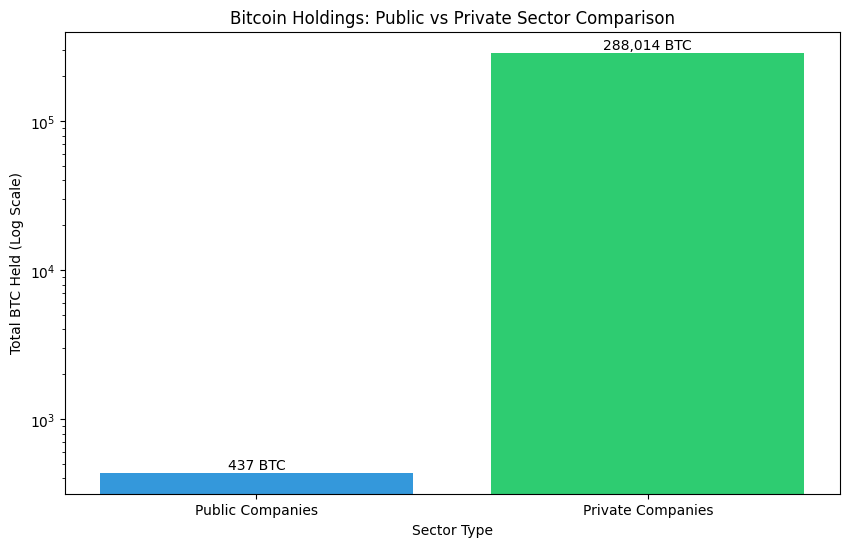

In [61]:
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, totals, color=['#3498db', '#2ecc71'])
plt.yscale('log') 

plt.title('Bitcoin Holdings: Public vs Private Sector Comparison')
plt.ylabel('Total BTC Held (Log Scale)')
plt.xlabel('Sector Type')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f} BTC', ha='center', va='bottom')

plt.show()
